In [1]:
#importing required python classes and packages
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from keras.utils.np_utils import to_categorical
import os
#loading resnet and attention model
from keras.applications.resnet50 import ResNet50, preprocess_input
from Attention import attention
from keras.preprocessing import image
from keras import layers, models, Input, Model
from keras.models import Sequential
from keras.layers import  MaxPooling2D, Conv2D, Flatten, Dense, Input, Concatenate, Dropout, RepeatVector
from sklearn.model_selection import train_test_split
from keras.callbacks import ModelCheckpoint
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
import pickle
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

Using TensorFlow backend.
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [2]:
#loading and displaying PDFUES metadata values
dataset = pd.read_csv("Dataset/Pdfues/metadata.csv")
pdfues_labels = np.unique(dataset['diagnostic']).ravel() #get PDFUES cancer diagnose unique labels
diagnose = dataset['diagnostic'].ravel() #get entire diagnose list
img_id = dataset['img_id'].ravel()#get image list
dataset

,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2293,PAT_1708,3156,NaN,NaN,NaN,NaN,73,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1708_3156_175.png,False
2294,PAT_46,880,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,12.0,BCC,True,True,False,True,False,False,PAT_46_880_140.png,True
2295,PAT_1343,1217,NaN,NaN,NaN,NaN,74,NaN,NaN,NaN,...,NaN,SEK,False,False,False,False,False,False,PAT_1343_1217_404.png,False
2296,PAT_326,690,False,False,POMERANIA,POMERANIA,58,True,FEMALE,True,...,4.0,BCC,True,False,False,False,False,True,PAT_326_690_823.png,True


In [3]:
#applying onehot encoding on categorical data and then replace all missing values
dataset.drop(['patient_id','lesion_id','img_id','diagnostic'], axis = 1,inplace=True)#drop irreleevant metadata columns
dataset.fillna(0, inplace = True)
label_encoder = []
columns = dataset.columns
types = dataset.dtypes.values
for j in range(len(types)):#loop each string column
    name = types[j]
    if name == 'object': #finding column with object type
        le = LabelEncoder()
        dataset[columns[j]] = pd.Series(le.fit_transform(dataset[columns[j]].astype(str)))#encode all str columns to numeric
        label_encoder.append([columns[j], le])
dataset.fillna(0, inplace = True)
dataset = dataset.astype(int)
dataset

,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,region,diameter_1,diameter_2,itch,grew,hurt,changed,bleed,elevation,biopsed
0,0,0,0,0,8,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,1,1,10,8,55,1,1,2,2,2,...,10,6,5,1,1,0,1,1,1,1
2,0,0,0,0,77,0,0,0,0,0,...,5,0,0,1,0,0,0,0,0,0
3,0,0,0,0,75,0,0,0,0,0,...,8,0,0,1,0,0,0,0,0,0
4,1,2,10,8,79,1,2,2,1,1,...,7,5,5,1,1,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2293,0,0,0,0,73,0,0,0,0,0,...,8,0,0,1,0,0,0,0,0,0
2294,1,1,10,8,55,1,1,2,2,2,...,3,13,12,1,1,0,1,0,0,1
2295,0,0,0,0,74,0,0,0,0,0,...,7,0,0,0,0,0,0,0,0,0
2296,1,1,10,8,58,2,1,2,2,1,...,5,5,4,1,0,0,0,0,1,1


In [4]:
#normalizing metadata features
dataset = dataset.values
scaler = StandardScaler()
dataset = scaler.fit_transform(dataset)
print("Normalized metadata features = "+str(dataset))

Normalized metadata features = [[-1.21472271 -1.17688864 -1.14957726 ... -0.6039793  -1.2871214
  -1.18480618]
 [ 0.43116926  0.2755765   1.18844251 ...  1.61318434  0.771198
   0.8440199 ]
 [-1.21472271 -1.17688864 -1.14957726 ... -0.6039793  -1.2871214
  -1.18480618]
 ...
 [-1.21472271 -1.17688864 -1.14957726 ... -0.6039793  -1.2871214
  -1.18480618]
 [ 0.43116926  0.2755765   1.18844251 ... -0.6039793   0.771198
   0.8440199 ]
 [-1.21472271 -1.17688864 -1.14957726 ... -0.6039793   0.771198
  -1.18480618]]


In [6]:
#loading resnet50 model for features extraction
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
print("Resnet50 model loaded")

Resnet50 model loaded


In [7]:
#function to get numeric label of given skin cancer name
def getLabel(name):
    index = -1
    for i in range(len(pdfues_labels)):
        if pdfues_labels[i] == name:
            index = i
            break
    return index

In [8]:
#function to return all augmented images of given image
def getAugmentedImages(name, cancer):
    image_list = []
    path = "Dataset/Pdfues/Augmented/"+cancer
    for root, dirs, directory in os.walk(path):
        for j in range(len(directory)):
            filename = directory[j]
            if "-" in filename:
                arr = filename.split("-")
                arr = arr[0]+".png"
                if arr == name:
                    image_list.append(path+"/"+directory[j])
            else:
                if filename == name:
                    image_list.append(path+"/"+directory[j])
    return image_list   

In [9]:
#read, process and extract features from images using resnet50
if os.path.exists("model/pdf_img.npy"):#if features already extracted then load them
    img = np.load("model/pdf_img.npy")
    X = np.load("model/pdf_X.npy")
    Y = np.load("model/pdf_Y.npy")
else:#if not processed then loop each image and then extract and merge meta data features
    for i in range(len(img_id)):
        image_name = img_id[i]
        image_label = getLabel(diagnose[i].strip())
        image_list = getAugmentedImages(image_name, diagnose[i].strip())
        for j in range(len(image_list)):
            X.append(dataset[i])
            Y.append(image_label)
            x = image.load_img(image_list[j], target_size=(64, 64))#read image
            x = image.img_to_array(x)
            x = np.expand_dims(x, axis=0) 
            x = preprocess_input(x)#process image as per resnet format
            img.append(x[0])
    img = np.asarray(img)
    X = np.asarray(X)
    Y = np.asarray(Y)
    img = resnet_model.predict(img)#apply resnet to extract features and the save all processed image features and metadata
    np.save("model/pdf_img",img)
    np.save("model/pdf_X",X)
    np.save("model/pdf_Y",Y)
print("Total images available in PDFUES dataset before applying Augmentation : "+str(dataset.shape[0]))    
print("Total features extracted from each image by Resnet50 = "+str(img.shape[1]))
img = np.reshape(img, (img.shape[0], 64, 32, 1))   
print("Total PDFUES images available in dataset after applying Augmentation= "+str(img.shape[0]))    

Total images available in PDFUES dataset before applying Augmentation : 2298
Total features extracted from each image by Resnet50 = 2048
Total PDFUES images available in dataset after applying Augmentation= 4560


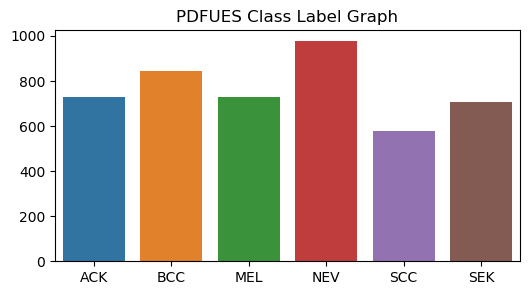

In [10]:
#graphs of different class labels available in dataset
unique, count = np.unique(Y,return_counts=True)
plt.figure(figsize=(6, 3))
sns.barplot(x=pdfues_labels,y=count)
plt.title("PDFUES Class Label Graph")
plt.show() 

In [11]:
#shuffling images and metadata features
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices] #X contains metadata
Y = Y[indices] #Y contains labels
img = img[indices] #img contains image features
Y = to_categorical(Y)
print("Features shuffling process completed")

Features shuffling process completed


In [18]:
#split dataset into train, test and validation for only images
X_train, X_test, y_train, y_test = train_test_split(img, Y, test_size=0.1, random_state=42, stratify=Y) 
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train) 

#split image and metadata features into train and test
X_img_train, X_img_test, X_meta_train, X_meta_test, y_trains, y_tests = train_test_split(img, X, Y, test_size=0.1, random_state=42, stratify=Y)
X_img_train, X_img_val, X_meta_train, X_meta_val, y_trains, y_vals = train_test_split(X_img_train, X_meta_train, y_trains, test_size=0.2, random_state=42, stratify=y_trains)

print("Dataset Split Details")
print("70% dataset features used to train algorithms : "+str(X_img_train.shape[0]))
print("10% dataset features used to test algorithms : "+str(X_img_test.shape[0]))
print("20% dataset features used to validate algorithms : "+str(X_img_val.shape[0]))

Dataset Split Details
70% dataset features used to train algorithms : 3283
10% dataset features used to test algorithms : 456
20% dataset features used to validate algorithms : 821


In [19]:
#function to evaluate model
def modelEvaluation(algorithm, testY, predict, prob):
    a = round(accuracy_score(testY,predict), 2)
    auc_value = roc_auc_score(testY,prob,multi_class='ovr')
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" AUC       : "+str(auc_value))
    print(classification_report(testY,predict, target_names=pdfues_labels))
    
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 5))
    ax = sns.heatmap(conf_matrix, xticklabels = pdfues_labels, yticklabels = pdfues_labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(pdfues_labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 
    color = ['red', 'green', 'blue', 'yellow', 'magenta', 'cyan']
    for i in range(len(pdfues_labels)):   
        fpr, tpr, thresh = roc_curve(testY, prob[:,i], pos_label=i)
        axs[1].plot(fpr, tpr, linestyle='--',color=color[i], label=pdfues_labels[i])
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    axs[1].legend()
    plt.show()

Image Only Model Accuracy  : 0.69
Image Only Model AUC       : 0.9413858439372
              precision    recall  f1-score   support

         ACK       0.66      0.74      0.70       131
         BCC       0.54      0.64      0.59       152
         MEL       0.84      0.89      0.87       131
         NEV       0.67      0.84      0.75       176
         SCC       0.73      0.41      0.53       104
         SEK       0.83      0.49      0.61       127

    accuracy                           0.69       821
   macro avg       0.71      0.67      0.67       821
weighted avg       0.70      0.69      0.68       821



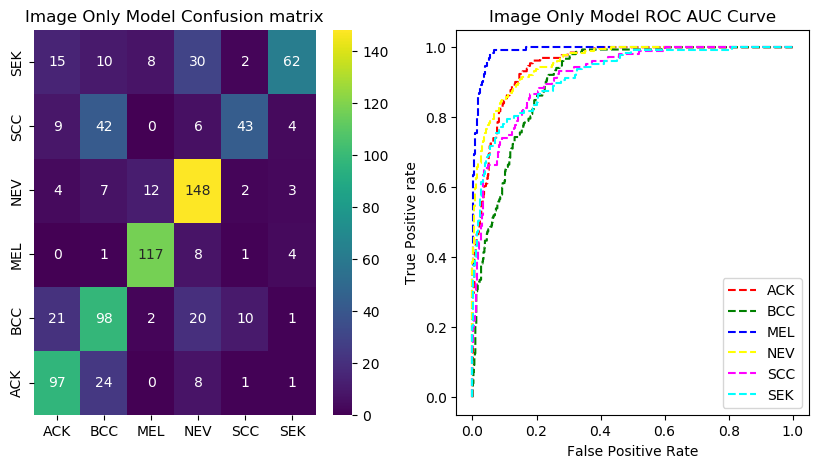

In [20]:
#training deep learning image only model
img_model = Sequential()
img_model.add(Conv2D(32, (3 , 3), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
img_model.add(MaxPooling2D(pool_size = (2, 2)))
img_model.add(Conv2D(64, (3, 3), activation = 'relu'))
img_model.add(MaxPooling2D(pool_size = (2, 2)))
img_model.add(Flatten())
img_model.add(Dense(units = 128, activation = 'relu'))
img_model.add(Dropout(0.5))
img_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compiling, training and loading model
img_model.compile(optimizer = "adam", loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/pdf_img_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/pdf_img_weights.hdf5', verbose = 1, save_best_only = True)
    hist = img_model.fit(aug.flow([X_train, y_train], batch_size = 32), epochs = 20, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/pdf_img_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    img_model.load_weights("model/pdf_img_weights.hdf5")
#perform prediction on validation data    
prob = img_model.predict(X_val)
predict = np.argmax(prob, axis=1)
y_test1 = np.argmax(y_val, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("Image Only Model", y_test1, predict, prob)

Image + Metadata Accuracy  : 0.77
Image + Metadata AUC       : 0.9607399592310255
              precision    recall  f1-score   support

         ACK       0.88      0.60      0.71       131
         BCC       0.63      0.85      0.72       152
         MEL       0.90      0.96      0.93       131
         NEV       0.95      0.84      0.89       176
         SCC       0.68      0.40      0.51       104
         SEK       0.66      0.88      0.76       127

    accuracy                           0.77       821
   macro avg       0.78      0.76      0.75       821
weighted avg       0.79      0.77      0.77       821



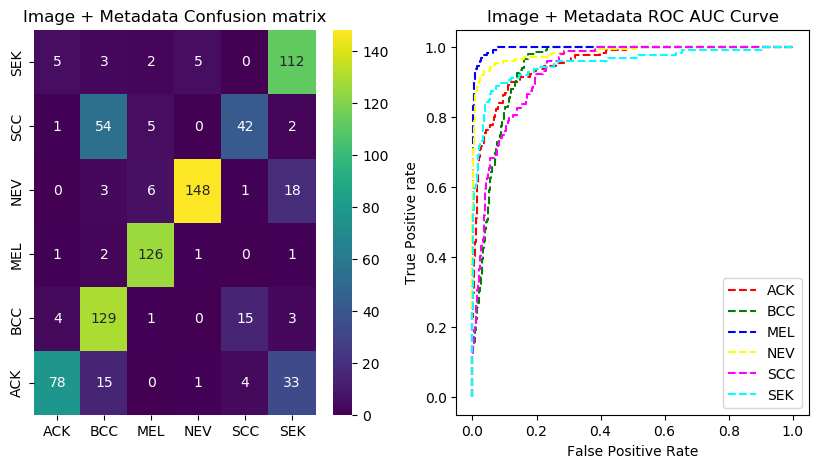

In [21]:
#training Image + Metadata (Concatenation) model
#split image and metadata features into train and test
data = np.load("model/pdf_data.npy", allow_pickle=True)
X_img_train, X_img_val, X_meta_train, X_meta_val, y_trains, y_vals = data
#defining image model
image_branch = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 32, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(64, activation='relu')
], name="Image_Branch")

#defining metadata model
meta_branch = Sequential([
    Dense(32, activation='relu', input_shape=(X.shape[1],)),
    Dense(16, activation='relu')
], name="Metadata_Branch")

#concatenating both models
combined_input = Concatenate()([image_branch.output, meta_branch.output])
# Final dense layers to process merged data
x = Dense(64, activation='relu')(combined_input)
output = Dense(Y.shape[1], activation='softmax')(x) # softmax activation for classification
meta_model = Model(inputs=[image_branch.input, meta_branch.input], outputs=output)
#compiling, training and loading model
meta_model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])
if os.path.exists("model/pdf_meta_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/pdf_meta_weights.hdf5', verbose = 1, save_best_only = True)
    hist = meta_model.fit(aug.flow([X_img_train, X_meta_train], y_trains,batch_size = 32), epochs = 20, validation_data=([X_img_test, X_meta_test], y_tests), callbacks=[model_check_point], verbose=1)
    f = open('model/pdf_meta_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    meta_model.load_weights("model/pdf_meta_weights.hdf5")
#perform prediction on test data
prob = meta_model.predict([X_img_val, X_meta_val])
predict = np.argmax(prob, axis=1)
y_test1 = np.argmax(y_vals, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("Image + Metadata", y_test1, predict, prob)

Attention-Multimodal Fusion Accuracy  : 0.8
Attention-Multimodal Fusion AUC       : 0.9604758779449784
              precision    recall  f1-score   support

         ACK       0.73      0.76      0.74       131
         BCC       0.64      0.78      0.70       152
         MEL       0.95      0.95      0.95       131
         NEV       0.93      0.90      0.91       176
         SCC       0.65      0.56      0.60       104
         SEK       0.88      0.76      0.81       127

    accuracy                           0.80       821
   macro avg       0.80      0.78      0.79       821
weighted avg       0.81      0.80      0.80       821



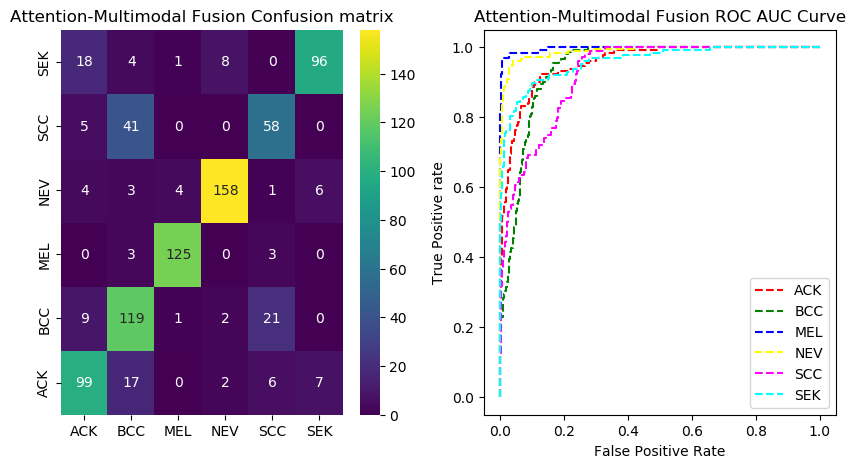

In [22]:
#Attention-based multimodal fusion
#defining image model with attention layer
image_branch = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 32, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    RepeatVector(2),
    attention(return_sequences=True,name='imgattention'),
    Flatten(),
    Dense(64, activation='relu')
], name="Image_Branch")

#defining metadata model with attention layer
meta_branch = Sequential([
    Dense(32, activation='relu', input_shape=(X.shape[1],)),
    RepeatVector(2),
    attention(return_sequences=True,name='metaattention'),
    Flatten(),
    Dense(16, activation='relu')
], name="Metadata_Branch")

#concatenate image and metadata model with attention layer
combined_input = Concatenate()([image_branch.output, meta_branch.output])
# Final dense layers to process merged data
x = Dense(64, activation='relu')(combined_input)
output = Dense(Y.shape[1], activation='softmax')(x) # softmax activation for classifictaion
attention_model = Model(inputs=[image_branch.input, meta_branch.input], outputs=output)
attention_model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])
#compiling, training and loading model
if os.path.exists("model/pdf_attention_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/pdf_attention_weights.hdf5', verbose = 1, save_best_only = True)
    hist = attention_model.fit(aug.flow([X_img_train, X_meta_train], y_trains,batch_size = 32), epochs = 20, validation_data=([X_img_test, X_meta_test], y_tests), callbacks=[model_check_point], verbose=1)
    f = open('model/pdf_attention_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    attention_model.load_weights("model/pdf_attention_weights.hdf5")
#perform prediction on test data
prob = attention_model.predict([X_img_val, X_meta_val])
predict = np.argmax(prob, axis=1)
y_test1 = np.argmax(y_vals, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("Attention-Multimodal Fusion", y_test1, predict, prob)